In [1]:
import math
import os
import pickle
import random
import sys

import shap
import torch

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import *

plt.rcParams.update({'font.size': 18})

# Explaining KAN With Shapley Value

The PyKAN trained in 3.1 is here loaded and explaining through the Shapley value technique.
OOriginating from game theory, the Shapley value is a powerful tool in the field of eXplainableAI. Through an iterative approximation, the features of the samples are randomly permuted and the distance in their prediction is used to understand how the model weights each of them to assert the engine's faulty state.

In [3]:
# 1s
df_x, df_y = read_dataset(stage='classification')

# Load the means and standard deviations of the train set used to train the model
norm = pd.read_csv('results/one_time_train_norm.csv').iloc[0]
means = norm[[f'{col}_mean' for col in df_x.columns]].values
stds = norm[[f'{col}_std' for col in df_x.columns]].values

In [10]:
dataset_x = torch.tensor(df_x.values, dtype=torch.float32)
dataset_x = (dataset_x - torch.tensor(means, dtype=torch.float32)) / torch.tensor(stds, dtype=torch.float32)

In [5]:
pyKAN: PHMNetwork = PyKAN([[len(df_x.columns), 0], [0, 1], [1, 0]], 'classification', device='cpu')

checkpoint directory created: ./model
saving model version 0.0


In [6]:
# 2s
pyKAN.load('fault_detection')
_, _, testset, _ = split_dataset(df_x, df_y['faulty'], train_ratio=0.15, standardize_y=False, max=1, seed=1)
pyKAN.test(testset)

100%|██████████| 39/39 [00:01<00:00, 26.61it/s]


{'test_loss': 0.12378364132765012,
 'avg_test_score': 0.8887756998974328,
 'accuracy': 0.9641241255196188,
 'precision': 0.9403124359840064,
 'recall': 0.972871137905049,
 'f1': 0.9563147437257663,
 'cm': array([[180357,   7867],
        [  3456, 123936]], dtype=int64)}

In [7]:
def explain_with_shap(tag: str, dataset, samples=1000):
    def model_predict(x):
        with torch.no_grad():
            x = torch.tensor(x, dtype=torch.float32)
            return pyKAN(x).numpy()

    random_indices = np.random.choice(len(dataset), size=samples, replace=False)
    random_samples = pd.DataFrame(dataset[random_indices], columns=df_x.columns)
    explainer = shap.Explainer(model_predict, random_samples.values)
    shap_values = explainer(random_samples.values)
    with open(f'{tag}_shapley.pkl', 'wb') as f:
        pickle.dump(shap_values, f)
    shap.summary_plot(shap_values.values, random_samples, plot_size=[18, 10], show=False)
    plt.savefig(f'img/{tag}_shapley.png', bbox_inches='tight', dpi=300)

<Axes: ylabel='Frequency'>

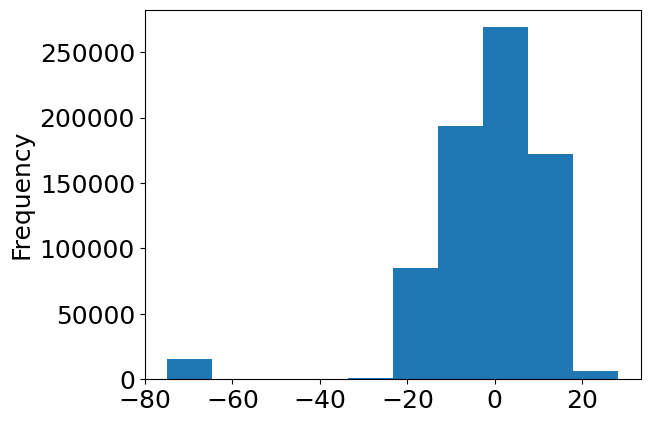

In [8]:
df_x['trq_margin'].plot(kind='hist')

ExactExplainer explainer: 601it [02:18,  4.05it/s]                         


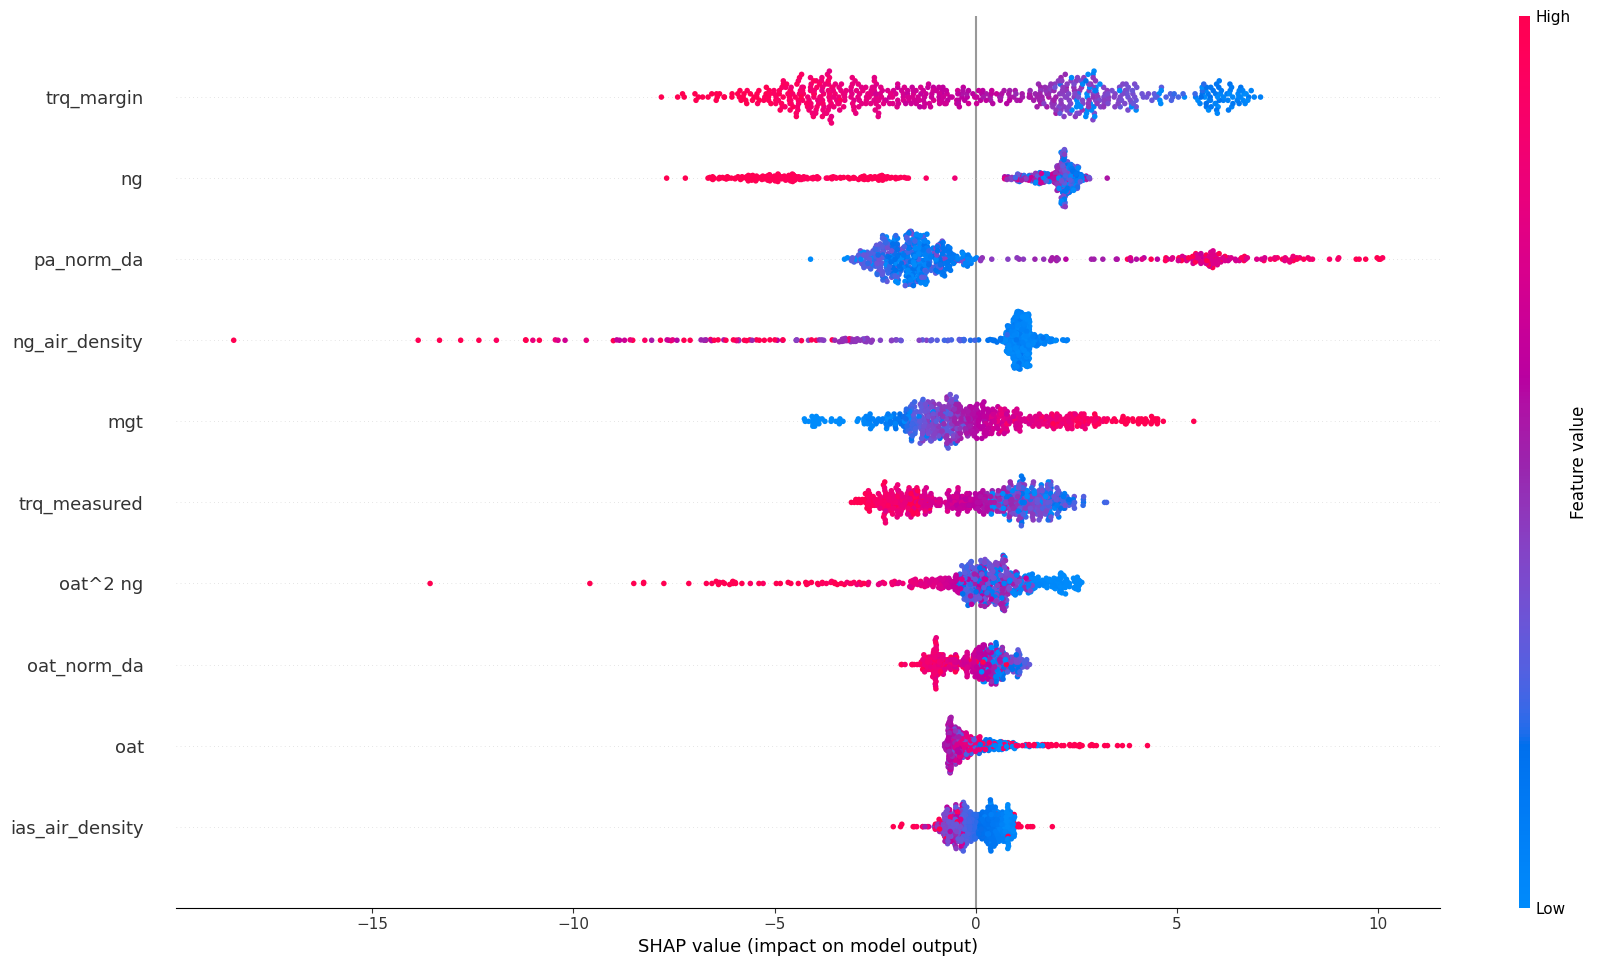

In [12]:
# 1m 20s
explain_with_shap('fault_detection', dataset_x, samples=600)